In [1]:
# Step 1. Load data labeled _mait_ at 500, 1000 and 1500 rpm.

from pathlib import Path
import re

import numpy as np
import pandas as pd
from IPython.display import display


DATA_DIR = Path("../data")
TARGET_RPMS = {500, 1000, 1500}

# ENV/SF can occur either before the RPM or before the current in legacy names.
MAIT_FILE_RE = re.compile(
    r"^analize_(?P<label>[a-z_]+?)(?P<experiment_id>\d+)"
    r"(?:_(?P<condition_before>ENV|SF))?_"
    r"(?P<rpm>\d+)rpm(?:_(?P<condition_after>ENV|SF))?_"
    r"(?P<current_ma>\d+)mA_mait\.csv$",
    re.IGNORECASE,
)

SAMPLE_COLUMNS = [
    "t_us", "ax", "ay", "az", "ax1", "ay1", "az1", "curr_raw",
]
SAMPLE_DTYPES = {column: np.int32 for column in SAMPLE_COLUMNS}

selected_files = []
excluded_condition_files = []
unmatched_files = []

for csv_path in sorted(DATA_DIR.glob("analize_*_mait.csv")):
    match = MAIT_FILE_RE.match(csv_path.name)
    if not match:
        unmatched_files.append(csv_path.name)
        continue

    metadata = match.groupdict()
    if metadata["condition_before"] or metadata["condition_after"]:
        excluded_condition_files.append(csv_path.name)
        continue

    rpm = int(metadata["rpm"])
    if rpm not in TARGET_RPMS:
        continue

    selected_files.append(
        {
            "path": csv_path,
            "source_file": csv_path.name,
            "state": metadata["label"].lower(),
            "experiment_id": int(metadata["experiment_id"]),
            "rpm": rpm,
            "current_ma": int(metadata["current_ma"]),
        }
    )

if not selected_files:
    raise FileNotFoundError(f"No matching mait CSV files found in {DATA_DIR.resolve()}")

state_dtype = pd.CategoricalDtype(sorted({record["state"] for record in selected_files}))
source_file_dtype = pd.CategoricalDtype([record["source_file"] for record in selected_files])
frames = []
file_records = []
for record in selected_files:
    sample_df = pd.read_csv(record["path"], usecols=SAMPLE_COLUMNS, dtype=SAMPLE_DTYPES)
    sample_df["state"] = pd.Categorical([record["state"]] * len(sample_df), dtype=state_dtype)
    sample_df["experiment_id"] = np.int16(record["experiment_id"])
    sample_df["rpm"] = np.int16(record["rpm"])
    sample_df["current_ma"] = np.int16(record["current_ma"])
    sample_df["source_file"] = pd.Categorical([record["source_file"]] * len(sample_df), dtype=source_file_dtype)
    frames.append(sample_df)
    file_records.append({**{key: value for key, value in record.items() if key != "path"}, "sample_count": len(sample_df)})

data_df = pd.concat(frames, ignore_index=True)
files_df = pd.DataFrame(file_records).sort_values(
    ["state", "experiment_id", "rpm", "current_ma"]
).reset_index(drop=True)

print(f"Loaded {len(files_df)} files and {len(data_df):,} samples.")
print(f"Excluded {len(excluded_condition_files)} ENV/SF file(s) from classification.")
display(files_df.groupby(["state", "rpm"]).agg(
    files=("source_file", "count"),
    samples=("sample_count", "sum"),
).reset_index())
if unmatched_files:
    print(f"Skipped {len(unmatched_files)} file(s) with an unrecognized name: {unmatched_files}")

Loaded 184 files and 21,818,443 samples.
Excluded 9 ENV/SF file(s) from classification.


,state,rpm,files,samples
0,front_ball,500,15,1284693
1,front_ball,1000,15,1201016
2,front_ball,1500,15,1197196
3,healthy,500,16,3402122
4,healthy,1000,17,3848480
5,healthy,1500,16,3356731
6,misalignment,500,15,1251410
7,misalignment,1000,15,1254397
8,misalignment,1500,15,1235851
9,rear_ball,500,15,1317639


In [2]:
# Step 2. Define train/test split and expected states. 

from sklearn.model_selection import train_test_split


EXPECTED_STATES = ("healthy", "front_ball", "rear_ball", "misalignment")
TEST_SIZE = 0.20
RANDOM_STATE = 42

STATE_TO_CLASS = {state: class_id for class_id, state in enumerate(EXPECTED_STATES)}
CLASS_TO_STATE = {class_id: state for state, class_id in STATE_TO_CLASS.items()}
SIGNAL_COLUMNS = [column for column in SAMPLE_COLUMNS if column != "t_us"]

observed_states = set(files_df["state"])
expected_state_set = set(EXPECTED_STATES)
if observed_states != expected_state_set:
    raise ValueError(
        f"Unexpected labels. Expected {sorted(expected_state_set)}, found {sorted(observed_states)}"
    )

# Split whole files, not individual samples, to prevent leakage between train and test data.
train_files_df, test_files_df = train_test_split(
    files_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=files_df["state"],
)
train_files_df = train_files_df.sort_values("source_file").reset_index(drop=True)
test_files_df = test_files_df.sort_values("source_file").reset_index(drop=True)

train_source_files = frozenset(train_files_df["source_file"])
test_source_files = frozenset(test_files_df["source_file"])
if train_source_files & test_source_files:
    raise RuntimeError("A source file appears in both train and test splits.")

split_summary_df = pd.concat(
    [
        train_files_df.assign(split="train"),
        test_files_df.assign(split="test"),
    ],
    ignore_index=True,
).groupby(["split", "state"], as_index=False).agg(
    files=("source_file", "count"),
    samples=("sample_count", "sum"),
)

display(split_summary_df)
print(f"Train files: {len(train_files_df)} | Test files: {len(test_files_df)}")

,split,state,files,samples
0,test,front_ball,9,724004
1,test,healthy,10,1718751
2,test,misalignment,9,783865
3,test,rear_ball,9,781672
4,train,front_ball,36,2958901
5,train,healthy,39,8888582
6,train,misalignment,36,2957793
7,train,rear_ball,36,3004875


Train files: 147 | Test files: 37


In [3]:
# Step 3. Build 200-sample raw analysis frames.

ANALYSIS_FRAME_SIZE = 200
RAW_FRAME_COLUMNS = [
    f"{signal}_sample_{sample_index}"
    for signal in SIGNAL_COLUMNS
    for sample_index in range(ANALYSIS_FRAME_SIZE)
]

analysis_frame_parts = []
dropped_samples = 0

# Frames are built separately for every file, so no frame can cross a file boundary.
for source_file, file_df in data_df.groupby("source_file", observed=True, sort=False):
    signal_values = file_df[SIGNAL_COLUMNS].to_numpy(dtype=np.float32)
    frame_count = len(signal_values) // ANALYSIS_FRAME_SIZE
    dropped_samples += len(signal_values) - frame_count * ANALYSIS_FRAME_SIZE
    if frame_count == 0:
        continue

    frames = signal_values[:frame_count * ANALYSIS_FRAME_SIZE].reshape(
        frame_count, ANALYSIS_FRAME_SIZE, len(SIGNAL_COLUMNS)
    )
    # Preserve every raw sample. Signals are grouped into contiguous blocks of 200 columns.
    raw_frame_values = frames.transpose(0, 2, 1).reshape(frame_count, -1)
    frame_part = pd.DataFrame(raw_frame_values, columns=RAW_FRAME_COLUMNS)
    frame_part["state"] = file_df["state"].iloc[0]
    frame_part["source_file"] = str(source_file)
    analysis_frame_parts.append(frame_part)

if not analysis_frame_parts:
    raise RuntimeError("No complete analysis frames were created.")

analysis_frames_df = pd.concat(analysis_frame_parts, ignore_index=True)
analysis_frames_df["state"] = pd.Categorical(
    analysis_frames_df["state"], categories=EXPECTED_STATES
)
analysis_frames_df["source_file"] = pd.Categorical(analysis_frames_df["source_file"])

model_columns = RAW_FRAME_COLUMNS + ["state"]
train_df = analysis_frames_df.loc[
    analysis_frames_df["source_file"].isin(train_source_files), model_columns
].copy()
test_df = analysis_frames_df.loc[
    analysis_frames_df["source_file"].isin(test_source_files), model_columns
].copy()
for split_df in (train_df, test_df):
    split_df["state_id"] = split_df["state"].map(STATE_TO_CLASS).astype(np.int8)

X_train = train_df[RAW_FRAME_COLUMNS]
y_train = train_df["state_id"]
X_test = test_df[RAW_FRAME_COLUMNS]
y_test = test_df["state_id"]

if set(y_train.unique()) != set(STATE_TO_CLASS.values()) or set(y_test.unique()) != set(STATE_TO_CLASS.values()):
    raise RuntimeError("Every expected state must be present in both splits.")

print(f"Created {len(analysis_frames_df):,} analysis frames of {ANALYSIS_FRAME_SIZE} samples.")
print(f"Dropped {dropped_samples:,} trailing samples that did not fill a complete frame.")
print(f"Train frames: {len(train_df):,} | Test frames: {len(test_df):,}")

Created 108,995 analysis frames of 200 samples.
Dropped 19,443 trailing samples that did not fill a complete frame.
Train frames: 88,973 | Test frames: 20,022


In [4]:
# Step 4. Use Optuna to find XGBoost hyperparameters.

import json

import optuna
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


N_TRIALS = 100
TUNING_VALIDATION_SIZE = 0.20
MAX_TRAIN_FRAMES_PER_STATE = 2_000
MAX_VALIDATION_FRAMES_PER_STATE = 500
N_ESTIMATORS = 150
EARLY_STOPPING_ROUNDS = 15


def detect_xgboost_device() -> str:
    # Return CUDA when XGBoost can actually train on the GPU; otherwise use CPU.
    try:
        probe = XGBClassifier(
            objective="multi:softprob",
            num_class=len(EXPECTED_STATES),
            n_estimators=1,
            tree_method="hist",
            device="cuda",
            eval_metric="mlogloss",
        )
        probe.fit(np.arange(16, dtype=np.float32).reshape(4, 4), np.arange(4))
        configured_device = json.loads(probe.get_booster().save_config())["learner"]["generic_param"]["device"]
        return "cuda" if configured_device.startswith("cuda") else "cpu"
    except Exception:
        return "cpu"


XGBOOST_DEVICE = detect_xgboost_device()
XGBOOST_N_JOBS = 1 if XGBOOST_DEVICE == "cuda" else -1
print(f"XGBoost device: {XGBOOST_DEVICE}")

# Keep the final test files untouched while Optuna tunes against a separate file-level validation split.
tuning_files_df, validation_files_df = train_test_split(
    train_files_df,
    test_size=TUNING_VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=train_files_df["state"],
)


def sample_balanced_frames(source_files, max_frames_per_state, seed):
    rng = np.random.default_rng(seed)
    source_mask = analysis_frames_df["source_file"].isin(source_files)
    sampled_indices = []

    for state in EXPECTED_STATES:
        state_indices = analysis_frames_df.index[source_mask & analysis_frames_df["state"].eq(state)].to_numpy()
        if len(state_indices) == 0:
            raise ValueError(f"No samples available for state {state!r}.")
        sample_size = min(max_frames_per_state, len(state_indices))
        sampled_indices.append(rng.choice(state_indices, size=sample_size, replace=False))

    sampled_indices = np.concatenate(sampled_indices)
    rng.shuffle(sampled_indices)
    sampled_df = analysis_frames_df.loc[sampled_indices, RAW_FRAME_COLUMNS + ["state"]]
    X = sampled_df[RAW_FRAME_COLUMNS]
    y = sampled_df["state"].map(STATE_TO_CLASS).astype(np.int8)
    return X, y


X_tune, y_tune = sample_balanced_frames(
    tuning_files_df["source_file"], MAX_TRAIN_FRAMES_PER_STATE, RANDOM_STATE
)
X_validation, y_validation = sample_balanced_frames(
    validation_files_df["source_file"], MAX_VALIDATION_FRAMES_PER_STATE, RANDOM_STATE + 1
)
print(f"Tuning frames: {len(X_tune):,} | Validation frames: {len(X_validation):,}")


def objective(trial):
    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(EXPECTED_STATES),
        eval_metric="mlogloss",
        tree_method="hist",
        device=XGBOOST_DEVICE,
        n_jobs=XGBOOST_N_JOBS,
        random_state=RANDOM_STATE,
        n_estimators=N_ESTIMATORS,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.20, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 7),
        min_child_weight=trial.suggest_float("min_child_weight", 1.0, 10.0, log=True),
        subsample=trial.suggest_float("subsample", 0.70, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.70, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
    )
    model.fit(X_tune, y_tune, eval_set=[(X_validation, y_validation)], verbose=False)
    return accuracy_score(y_validation, model.predict(X_validation))


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=2),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_xgb_params = {
    "objective": "multi:softprob",
    "num_class": len(EXPECTED_STATES),
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "device": XGBOOST_DEVICE,
    "n_jobs": XGBOOST_N_JOBS,
    "random_state": RANDOM_STATE,
    "n_estimators": N_ESTIMATORS,
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
    **study.best_params,
}

print(f"Best validation accuracy: {study.best_value:.4f}")
display(pd.DataFrame([best_xgb_params]))

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoost device: cuda


[I 2026-07-15 10:01:42,210] A new study created in memory with name: no-name-446ca342-44af-4973-8b0d-b2600a0547c2


Tuning frames: 8,000 | Validation frames: 2,000


  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:729: UserWarning: [10:02:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
Best trial: 0. Best value: 0.715:   1%|          | 1/100 [00:37<1:02:07, 37.66s/it]

...

Best trial: 89. Best value: 0.7535:  99%|█████████▉| 99/100 [36:16<00:11, 11.44s/it]

[I 2026-07-15 10:37:58,684] Trial 98 finished with value: 0.708 and parameters: {'learning_rate': 0.17317518556209419, 'max_depth': 3, 'min_child_weight': 2.9482482191042263, 'subsample': 0.7816259542009616, 'colsample_bytree': 0.8088129866405743, 'reg_lambda': 0.29520749665462126}. Best is trial 89 with value: 0.7535.


Best trial: 89. Best value: 0.7535: 100%|██████████| 100/100 [36:28<00:00, 21.89s/it]

[I 2026-07-15 10:38:10,964] Trial 99 finished with value: 0.744 and parameters: {'learning_rate': 0.1800735140020219, 'max_depth': 4, 'min_child_weight': 3.505788378765274, 'subsample': 0.7274679991754736, 'colsample_bytree': 0.7969678357327994, 'reg_lambda': 0.4875975526748572}. Best is trial 89 with value: 0.7535.
Best validation accuracy: 0.7535


,objective,num_class,eval_metric,tree_method,device,n_jobs,random_state,n_estimators,early_stopping_rounds,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda
0,multi:softprob,4,mlogloss,hist,cuda,1,42,150,15,0.197103,4,3.564563,0.786282,0.852521,0.312965


In [5]:
# Step 5. Train and evaluate the final XGBoost classifier with the selected hyperparameters.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier



# Best parameters from Optuna  
FINAL_XGB_PARAMS = {
    "objective": "multi:softprob",
    "num_class": len(EXPECTED_STATES),
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "device": "cuda",
    "n_jobs": 1,
    "random_state": RANDOM_STATE,
    "n_estimators": 150,
    "learning_rate": 0.11801533584769051,
    "max_depth": 5,
    "min_child_weight": 2.900830081836883,
    "subsample": 0.7027069187171897,
    "colsample_bytree": 0.875790467670702,
    "reg_lambda": 3.621483272502087,
}
# Final test accuracy: 0.8637
#               precision    recall  f1-score   support

#      healthy       0.90      0.99      0.94      8588
#   front_ball       0.83      0.69      0.75      3616
#    rear_ball       0.74      0.92      0.82      3903
# misalignment       0.99      0.70      0.82      3915

#     accuracy                           0.86     20022
#    macro avg       0.87      0.82      0.83     20022
# weighted avg       0.87      0.86      0.86     20022


# FINAL_XGB_PARAMS = {
#     "objective": "multi:softprob",
#     "num_class": len(EXPECTED_STATES),
#     "eval_metric": "mlogloss",
#     "tree_method": "hist",
#     "device": "cuda",
#     "n_jobs": 1,
#     "random_state": RANDOM_STATE,
#     "n_estimators": 150,
#     "learning_rate": 0.1650240869321279,
#     "max_depth": 4,
#     "min_child_weight": 2.745900008601542,
#     "subsample": 0.8039896843488356,
#     "colsample_bytree": 0.8587794347924431,
#     "reg_lambda": 0.3439762998968361,
# }
# Final test accuracy: 0.8583
#               precision    recall  f1-score   support

#      healthy       0.89      0.99      0.93      8588
#   front_ball       0.85      0.68      0.75      3616
#    rear_ball       0.74      0.90      0.81      3903
# misalignment       0.98      0.69      0.81      3915

#     accuracy                           0.86     20022
#    macro avg       0.86      0.82      0.83     20022
# weighted avg       0.87      0.86      0.85     20022



# Train on every analysis frame in the training split. The test split remains untouched.
final_xgb_classifier = XGBClassifier(**FINAL_XGB_PARAMS)
final_xgb_classifier.fit(X_train, y_train, verbose=False)

test_pred_id = final_xgb_classifier.predict(X_test).astype(np.int8)
test_accuracy = accuracy_score(y_test, test_pred_id)
test_classification_report = classification_report(
    y_test,
    test_pred_id,
    labels=list(CLASS_TO_STATE),
    target_names=[CLASS_TO_STATE[class_id] for class_id in CLASS_TO_STATE],
    zero_division=0,
)
test_report_df = pd.DataFrame(
    classification_report(
        y_test,
        test_pred_id,
        labels=list(CLASS_TO_STATE),
        target_names=[CLASS_TO_STATE[class_id] for class_id in CLASS_TO_STATE],
        output_dict=True,
        zero_division=0,
    )
).T
test_confusion_df = pd.DataFrame(
    confusion_matrix(y_test, test_pred_id, labels=list(CLASS_TO_STATE)),
    index=pd.Index([CLASS_TO_STATE[class_id] for class_id in CLASS_TO_STATE], name="actual_state"),
    columns=pd.Index([CLASS_TO_STATE[class_id] for class_id in CLASS_TO_STATE], name="predicted_state"),
)

print(f"Final test accuracy: {test_accuracy:.4f}")
print(test_classification_report)
display(test_report_df)
display(test_confusion_df)

Final test accuracy: 0.8637
              precision    recall  f1-score   support

     healthy       0.90      0.99      0.94      8588
  front_ball       0.83      0.69      0.75      3616
   rear_ball       0.74      0.92      0.82      3903
misalignment       0.99      0.70      0.82      3915

    accuracy                           0.86     20022
   macro avg       0.87      0.82      0.83     20022
weighted avg       0.87      0.86      0.86     20022



,precision,recall,f1-score,support
healthy,0.901380,0.988705,0.943025,8588.00000
front_ball,0.832387,0.689436,0.754198,3616.00000
rear_ball,0.737472,0.916218,0.817185,3903.00000
misalignment,0.991298,0.698340,0.819422,3915.00000
accuracy,0.863750,0.863750,0.863750,0.86375
macro avg,0.865634,0.823175,0.833457,20022.00000
weighted avg,0.874550,0.863750,0.860223,20022.00000


predicted_state,healthy,front_ball,rear_ball,misalignment
actual_state,,,,
healthy,8491,0,97,0
front_ball,173,2493,948,2
rear_ball,177,128,3576,22
misalignment,579,374,228,2734


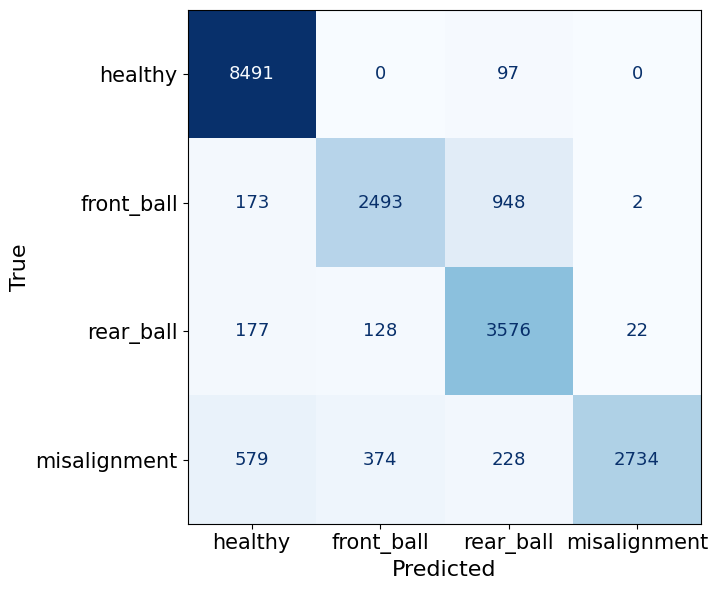

In [6]:
# Step 6. Plot the final test-set confusion matrix.

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


class_names = [CLASS_TO_STATE[class_id] for class_id in CLASS_TO_STATE]
fig, ax = plt.subplots(figsize=(7, 6))
display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_df.to_numpy(),
    display_labels=class_names,
)
display_matrix.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",
    text_kw={"fontsize": 13},
)
# ax.set_title("XGBoost Test Confusion Matrix", fontsize=16)
ax.set_xlabel("Predicted", fontsize=16)
ax.set_ylabel("True", fontsize=16)
ax.tick_params(axis="both", labelsize=15)
fig.tight_layout()
plt.show()